In [12]:
"""
FINUFFT
Here I provide a first try at getting FINUFFT to work. The first step is to install finufft on Tycho,
as far as I recall I simply did

pip install finufft
"""

import finufft
import paicos as pa
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# Load a snapshot and select spherical region (?)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
snap = pa.Snapshot(pa.data_dir, 247)
center = snap.Cat.Group['GroupPos'][0]
R200c = snap.Cat.Group['Group_R_Crit200'][0]
r_max = 1.0 * R200c
# index = pa.util.get_index_of_radial_range(snap['0_Coordinates'], center, 0., r_max)

widths = np.array([2e3, 2e3, 2e3], dtype=float)
index = pa.util.get_index_of_cubic_region(snap['0_Coordinates'], center, widths, snap.box)
snap = snap.select(index, parttype=0)



In [13]:
snap['0_Coordinates'].shape

(12515, 3)

In [15]:
snap['0_Coordinates'][:, 0]

<PaicosQuantity [398974.38664031, 398976.06220306, 398964.31625223, ...,
                 398188.35831544, 399801.08658404, 399808.65546007] arepo_length small_a / small_h>

In [20]:
M = snap['0_Coordinates'].shape[0]
# A simple example,
# https://finufft.readthedocs.io/en/latest/python.html#quick-start-examples
# https://finufft.readthedocs.io/en/latest/python.html#finufft.Plan


# k1 = 1.0 * 2 * np.pi
# k2 = 0.0 * 2 * np.pi
# k3 = 0.0 * 2 * np.pi

# the nonuniform points (rescaled to -1 to 1), should be -pi to pi?
# x = (snap['0_Coordinates'][:, 0] - center[0]).value / R200c.value
# y = (snap['0_Coordinates'][:, 1] - center[1]).value / R200c.value
# z = (snap['0_Coordinates'][:, 2] - center[2]).value / R200c.value

# I think it should be 0, 2pi

x = 2 * np.pi * (snap['0_Coordinates'][:, 0].value - ( center[0].value - widths[0]/2. )) / widths[0]
y = 2 * np.pi * (snap['0_Coordinates'][:, 1].value - ( center[1].value - widths[1]/2. )) / widths[1]
z = 2 * np.pi * (snap['0_Coordinates'][:, 2].value - ( center[2].value - widths[2]/2. )) / widths[2]

# # their complex strengths
# c = snap['0_Density'].value + 0.0j
c = (np.random.standard_normal(size=M)
     + 1J * 0.0)

In [33]:
grid_size = 10
# c = np.exp(1j*k1*x + 1j*k2*y + 1j*k3*z).real + 0.0j

# # desired number of Fourier modes

kx = np.arange(0, grid_size)*1.0
ky = np.arange(0, grid_size)*1.0
kz = np.arange(0, grid_size)*1.0

# kx = np.logspace(-2, 2, grid_size)*2*np.pi
# ky = np.logspace(-2, 2, grid_size)*2*np.pi
# kz = np.logspace(-2, 2, grid_size)*2*np.pi

kxx, kyy, kzz = np.meshgrid(kx, ky, kz)

kx = kxx.flatten()
ky = kyy.flatten()
kz = kzz.flatten()


# calculate the NUFFT
f = finufft.nufft3d3(x, y, z, c, kx, ky, kz)
k = np.sqrt(kx**2 + ky**2 + kz**2)
# k_index = np.argsort(k)
# k1d = k[k_index]
# f1d = f[k_index]

# kxmax = (2.0 * np.pi / widths[0]) * (M / 2 - 1)
# kxmax = (2.0 * np.pi / widths[0]) * (M / 2 - 1)
# kxmax = (2.0 * np.pi / widths[0]) * (M / 2 - 1)
# kmax = 
kmin = k.min()
kmax = k.max()

k1d = np.arange(kmin, kmax+1.0, 1.0)
power1d = np.zeros(k1d.shape)

for i in range(k1d.shape[0]):
    indices = np.argwhere(k==k1d[i])
    if (indices.size != 0):
        power1d[i] = np.sum(np.abs(f[indices]))



In [37]:
kmax

15.588457268119896

In [36]:
k1d

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16.])

In [34]:
power1d

array([ 147.64750284,  254.42481237,  447.90710233,  551.83969357,
        291.50381445,  862.90532931,  713.3892025 ,  903.70264389,
        392.60143429, 1314.42239761,  641.1100492 ,  979.28124831,
        195.25224082,    0.        ,    0.        ,    0.        ,
          0.        ])

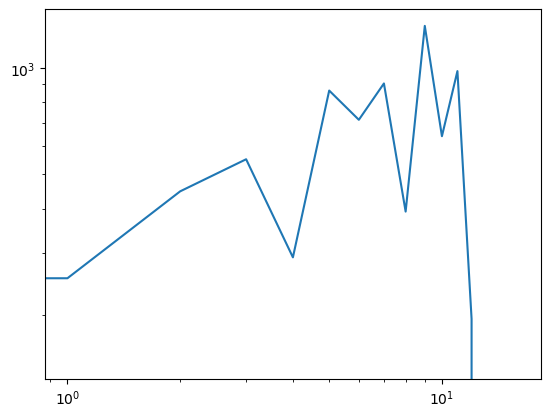

In [35]:

plt.figure(1)
plt.clf()
plt.loglog(k1d, power1d)
plt.show()

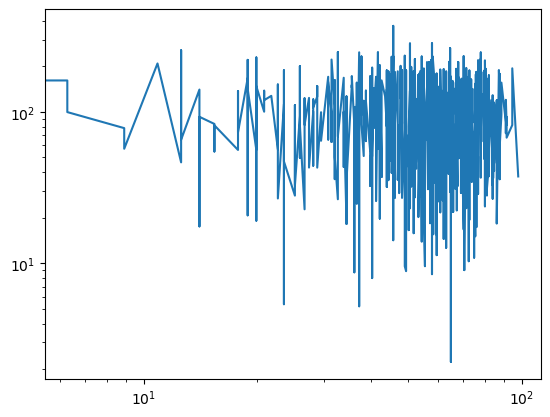

In [23]:

plt.figure(1)
plt.clf()
plt.loglog(k1d, np.abs(f1d))
plt.show()